In [5]:
import cnn_predict
import cv2
import torch
from matplotlib import pyplot as plt

In [13]:
# load glass image
glass_img_path = "./images/test_images/success_14.jpg"
glass_img = cv2.imread(glass_img_path)

# load model
model_path = "./cnn_checkpoints/cnn_best_model_epoch_50_acc_100.00.pth"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bot_model = cnn_predict.load_model(model_path, device)

Model loaded successfully.


In [14]:
predictive_decision, text_color = cnn_predict.predict_single_static(glass_img, bot_model, device)
print("Predictive decision: ", predictive_decision)

Predictive decision:  Success (0.72)


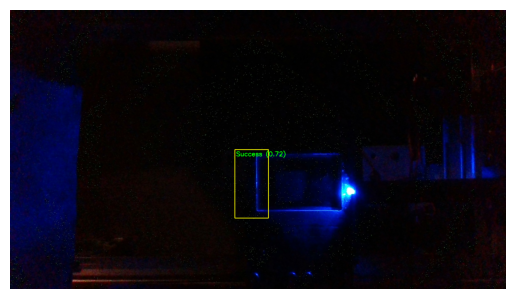

In [ ]:
ROI_X = 870
ROI_Y = 260
ROI_WIDTH = 130
ROI_HEIGHT = 265
ROI_OFFSET = 280

cv2.rectangle(glass_img, (ROI_X, ROI_Y + ROI_OFFSET), (ROI_X + ROI_WIDTH, ROI_Y + ROI_OFFSET + ROI_HEIGHT), (0, 255, 255), 2) # Yellow ROI box
cv2.putText(glass_img, predictive_decision, (ROI_X + 5, ROI_Y + ROI_OFFSET + 25), # Position near top-left of ROI
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, text_color, 2)

# Show the frame
img_rgb = cv2.cvtColor(glass_img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off') 
plt.show()